In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.metrics import r2_score

from tensorflow.keras.optimizers import SGD

from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# X, y
X = df.drop('target', axis = 1)

y = df['target']

In [7]:
# train test
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
#scaling
scaler = StandardScaler()

In [11]:
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [17]:
# nn
model = Sequential()
# model.add(Dense())
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.5, nesterov=True), loss='mse', metrics=['mse'])

In [23]:
#train
history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.9284 - mse: 0.9284 - val_loss: 0.4623 - val_mse: 0.4623
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4245 - mse: 0.4245 - val_loss: 0.4259 - val_mse: 0.4259
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4008 - mse: 0.4008 - val_loss: 0.4084 - val_mse: 0.4084
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3764 - mse: 0.3764 - val_loss: 0.4034 - val_mse: 0.4034
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3737 - mse: 0.3737 - val_loss: 0.3821 - val_mse: 0.3821
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3445 - mse: 0.3445 - val_loss: 0.3805 - val_mse: 0.3805
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3449 - mse: 0.3449 - val_loss: 0.3673 - val_mse: 0.3673
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3098 - mse: 0.3098 - val_loss: 0.3565 - val_mse: 0.3565
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

In [33]:
history.history['mse']

[0.5950892567634583,
 0.41744571924209595,
 0.40188637375831604,
 0.38292768597602844,
 0.3588990569114685,
 0.34418785572052,
 0.33785784244537354,
 0.3247750401496887,
 0.32302331924438477,
 0.31593045592308044,
 0.3078642785549164,
 0.30605801939964294,
 0.302427738904953,
 0.2970850169658661,
 0.2967165410518646,
 0.2927597761154175,
 0.3199470043182373,
 0.29794082045555115,
 0.2905901074409485,
 0.2873817980289459]

In [35]:
#EVAL
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [37]:
r2_score(y_test, y_pred)

0.7718489461725714

In [45]:
test_loss, test_mae = model.evaluate(X_test, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2944 - mse: 0.2944


In [47]:
def plot_metrics(history, y_test, y_pred, test_loss, test_mae, metric_name):
    plt.plot(history.history[metric_name], label=f'Training {metric_name}')
    plt.plot(history.history[f'val_{metric_name}'], label=f'Validation {metric_name}')
    if metric_name == 'loss':
        plt.scatter(len(history.history[metric_name]) - 1, test_loss, color='red', label='Test Loss')
    else:
        plt.scatter(len(history.history[metric_name]) - 1, test_mae, color='red', label='Test MAE')
    plt.xlabel('Epochs')
    plt.ylabel(metric_name.capitalize())
    plt.legend()
    plt.show()

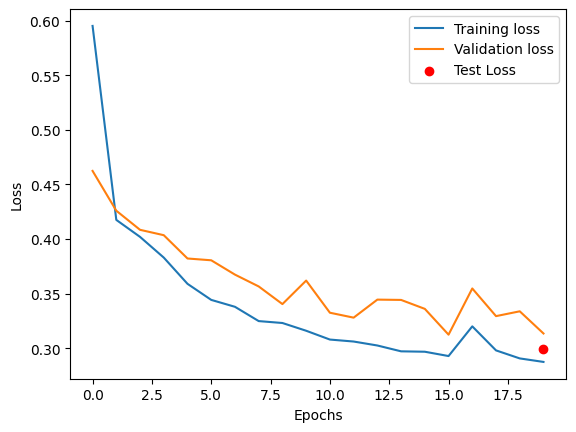

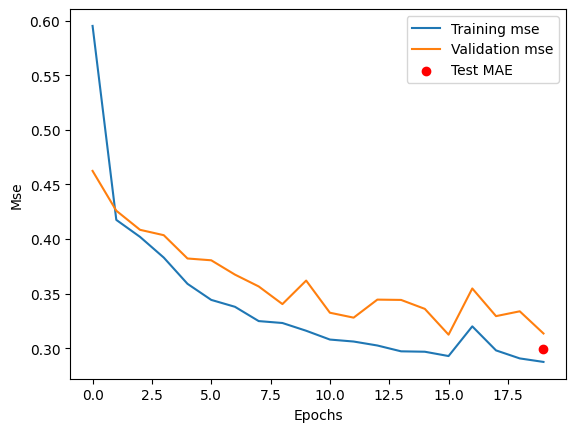

In [51]:
plot_metrics(history, y_test, y_pred, test_loss, test_mae, 'loss')
plot_metrics(history, y_test, y_pred, test_loss, test_mae, 'mse')